Blood Cell Image Classification Using Convolutional Neural Networks

In [1]:
# 1. Install libraries
!pip -q install medmnist scikit-learn seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00


In [2]:
# 2. Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import medmnist
from medmnist import INFO
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 3. Load BloodMNIST
data_flag = 'bloodmnist'
download = True
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])
n_classes = len(info['label'])

train_dataset = DataClass(split='train', download=download)
val_dataset = DataClass(split='val', download=download)
test_dataset = DataClass(split='test', download=download)

x_train, y_train = train_dataset.imgs, train_dataset.labels
x_val, y_val = val_dataset.imgs, val_dataset.labels
x_test, y_test = test_dataset.imgs, test_dataset.labels

print('Train:', x_train.shape, y_train.shape)
print('Validation:', x_val.shape, y_val.shape)
print('Test:', x_test.shape, y_test.shape)
print('Labels:', info['label'])

100%|██████████| 35.5M/35.5M [00:36<00:00, 961kB/s]


Train: (11959, 28, 28, 3) (11959, 1)
Validation: (1712, 28, 28, 3) (1712, 1)
Test: (3421, 28, 28, 3) (3421, 1)
Labels: {'0': 'basophil', '1': 'eosinophil', '2': 'erythroblast', '3': 'immature granulocytes(myelocytes, metamyelocytes and promyelocytes)', '4': 'lymphocyte', '5': 'monocyte', '6': 'neutrophil', '7': 'platelet'}


In [4]:
# 4. Class names
class_names = {
    0: 'Basophil',
    1: 'Eosinophil',
    2: 'Erythroblast',
    3: 'Immature granulocytes',
    4: 'Lymphocyte',
    5: 'Monocyte',
    6: 'Neutrophil',
    7: 'Platelet'
}
print(class_names)

{0: 'Basophil', 1: 'Eosinophil', 2: 'Erythroblast', 3: 'Immature granulocytes', 4: 'Lymphocyte', 5: 'Monocyte', 6: 'Neutrophil', 7: 'Platelet'}


In [5]:
# 5. Preprocessing
x_train = x_train.astype('float32') / 255.0
x_val = x_val.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

y_train_cat = to_categorical(y_train, num_classes=n_classes)
y_val_cat = to_categorical(y_val, num_classes=n_classes)
y_test_cat = to_categorical(y_test, num_classes=n_classes)

print('x_train:', x_train.shape, 'y_train_cat:', y_train_cat.shape)

x_train: (11959, 28, 28, 3) y_train_cat: (11959, 8)


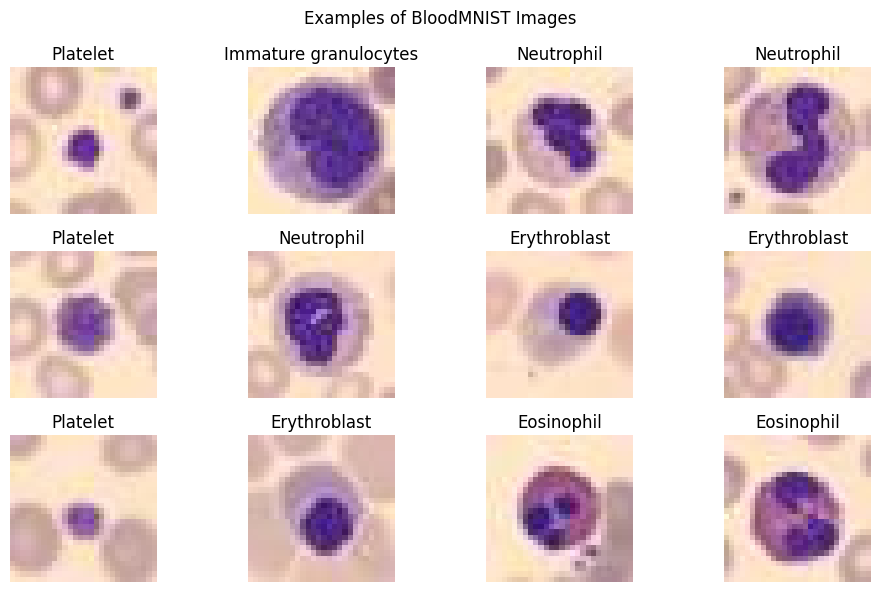

In [6]:
# 6. Example images
plt.figure(figsize=(10, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    label = int(y_train[i][0])
    plt.title(class_names[label])
    plt.axis('off')
plt.suptitle('Examples of BloodMNIST Images')
plt.tight_layout()
plt.show()

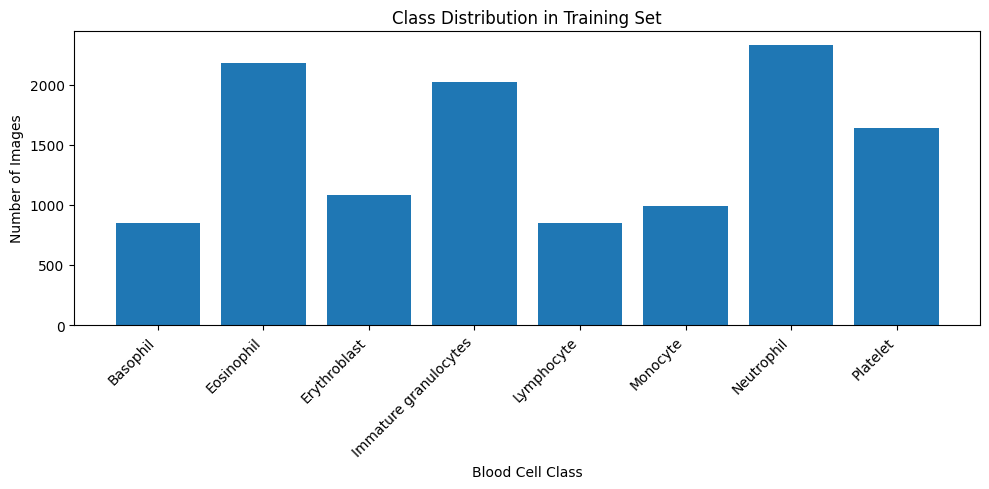

Basophil: 852
Eosinophil: 2181
Erythroblast: 1085
Immature granulocytes: 2026
Lymphocyte: 849
Monocyte: 993
Neutrophil: 2330
Platelet: 1643


In [7]:
# 7. Class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(10, 5))
plt.bar([class_names[int(i)] for i in unique], counts)
plt.title('Class Distribution in Training Set')
plt.xlabel('Blood Cell Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
for label, count in zip(unique, counts):
    print(f'{class_names[int(label)]}: {count}')

In [8]:
# 8. CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.40),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.50),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 437,544 (1.67 MB)

 Trainable params: 437,096 (1.67 MB)

 Non-trainable params: 448 (1.75 KB)

In [9]:
# 9. Training
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
checkpoint = ModelCheckpoint('best_bloodmnist_cnn_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/40
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.3852 - loss: 1.9455
Epoch 1: val_accuracy improved from None to 0.13727, saving model to best_bloodmnist_cnn_model.keras

Epoch 1: finished saving model to best_bloodmnist_cnn_model.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 62s 305ms/step - accuracy: 0.5094 - loss: 1.3858 - val_accuracy: 0.1373 - val_loss: 7.7522
Epoch 2/40
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.7456 - loss: 0.7032
Epoch 2: val_accuracy improved from 0.13727 to 0.29322, saving model to best_bloodmnist_cnn_model.keras

Epoch 2: finished saving model to best_bloodmnist_cnn_model.keras
187/187 ━━━━━━━━━━━━━━━━━━━━ 81s 302ms/step - accuracy: 0.7673 - loss: 0.6450 - val_accuracy: 0.2932 - val_loss: 4.2615
Epoch 3/40
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.8032 - loss: 0.5375
Epoch 3: val_accuracy improved from 0.29322 to 0.70035, saving model to best_bloodmnist_cnn_model.keras

Epoch 3: finished saving model to best_bloodmnist_cn

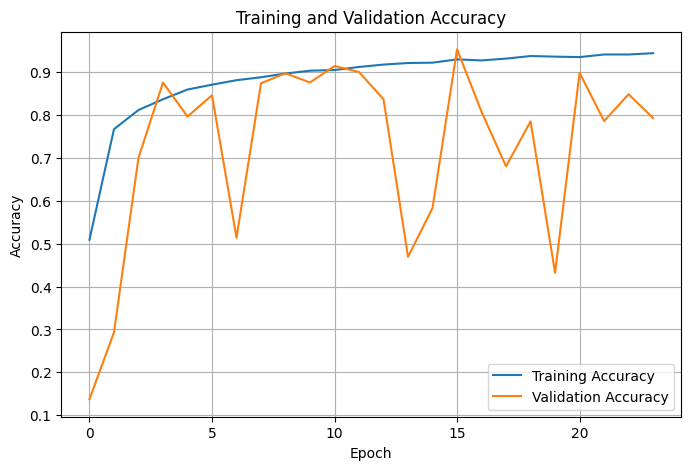

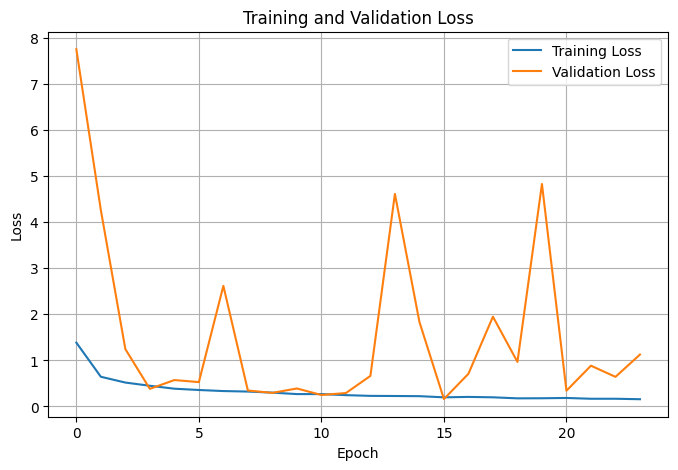

In [10]:
# 10. Accuracy and loss curves
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# 11. Test evaluation
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')

107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9412 - loss: 0.1854
Test Loss: 0.1854
Test Accuracy: 94.12%


107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step


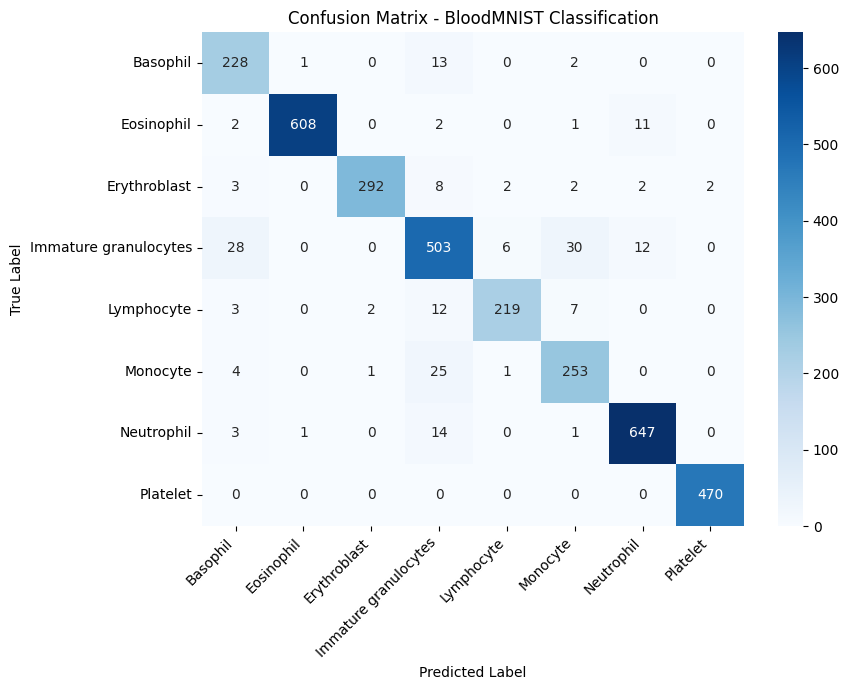

                       precision    recall  f1-score   support

             Basophil       0.84      0.93      0.89       244
           Eosinophil       1.00      0.97      0.99       624
         Erythroblast       0.99      0.94      0.96       311
Immature granulocytes       0.87      0.87      0.87       579
           Lymphocyte       0.96      0.90      0.93       243
             Monocyte       0.85      0.89      0.87       284
           Neutrophil       0.96      0.97      0.97       666
             Platelet       1.00      1.00      1.00       470

             accuracy                           0.94      3421
            macro avg       0.93      0.93      0.93      3421
         weighted avg       0.94      0.94      0.94      3421



In [12]:
# 12. Confusion matrix and classification report
y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[i] for i in range(n_classes)],
            yticklabels=[class_names[i] for i in range(n_classes)])
plt.title('Confusion Matrix - BloodMNIST Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=[class_names[i] for i in range(n_classes)]))

Macro-average ROC AUC: 0.9965


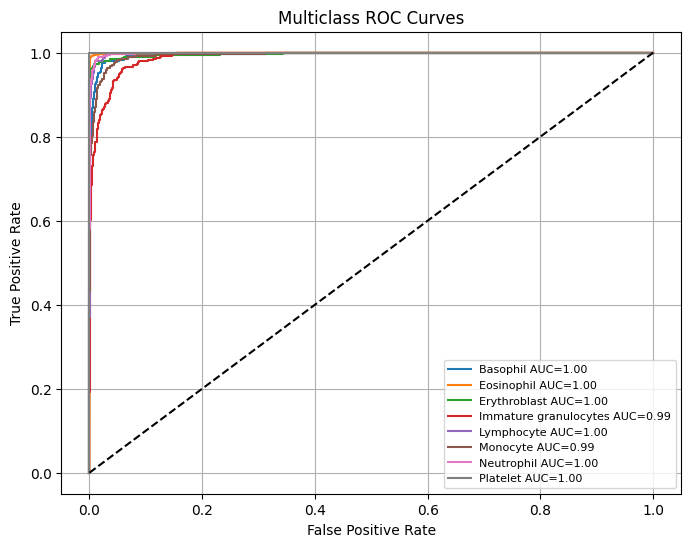

In [13]:
# 13. Multiclass ROC/AUC
y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
auc_macro = roc_auc_score(y_true_bin, y_pred_probs, average='macro', multi_class='ovr')
print(f'Macro-average ROC AUC: {auc_macro:.4f}')

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_names[i]} AUC={roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves')
plt.legend(fontsize=8)
plt.grid(True)
plt.show()

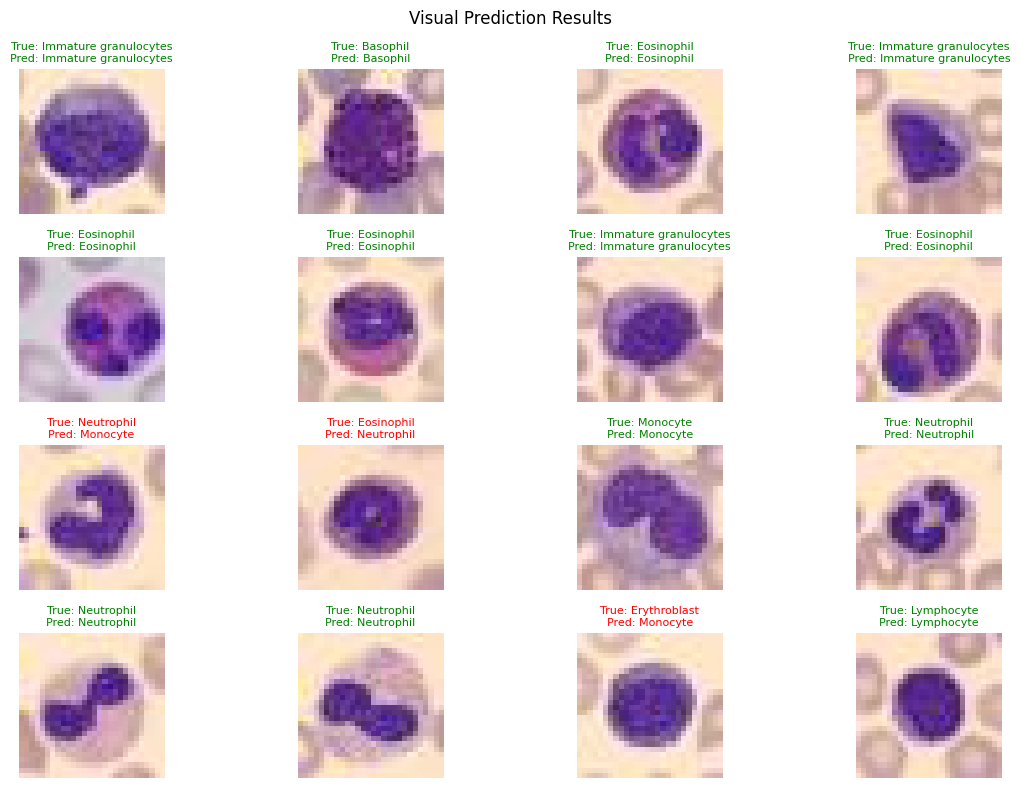

In [14]:
# 14. Visual predictions
plt.figure(figsize=(12, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_test[i])
    true_label = int(y_true[i])
    predicted_label = int(y_pred[i])
    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f'True: {class_names[true_label]}\nPred: {class_names[predicted_label]}', color=color, fontsize=8)
    plt.axis('off')
plt.suptitle('Visual Prediction Results')
plt.tight_layout()
plt.show()

In [15]:
# 15. Save model
model.save('bloodmnist_cnn_final_model.keras')
print('Model saved as bloodmnist_cnn_final_model.keras')

Model saved as bloodmnist_cnn_final_model.keras
